In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import firebase_admin
from firebase_admin import credentials, firestore
import matplotlib.pyplot as plt
import numpy as np
import base64
import json
import os

# Conditional VAE Model
class CVAE(nn.Module):
	def __init__(self, latent_dim=64, condition_dim=1):
		super(CVAE, self).__init__()
		self.latent_dim = latent_dim

		self.enc_conv1 = nn.Conv2d(4, 16, kernel_size=4, stride=2, padding=1)
		self.enc_conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1)

		self.flatten_dim = 32000

		self.fc_mu = nn.Linear(self.flatten_dim + condition_dim, latent_dim)
		self.fc_logvar = nn.Linear(self.flatten_dim + condition_dim, latent_dim)

		self.dec_fc = nn.Linear(latent_dim + condition_dim, self.flatten_dim)
		self.dec_conv1 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)
		self.dec_conv2 = nn.ConvTranspose2d(16, 4, kernel_size=4, stride=2, padding=1)

	def encode(self, x, c):
		x = F.relu(self.enc_conv1(x))
		x = F.relu(self.enc_conv2(x))
		x = x.view(-1, self.flatten_dim)
		x_c = torch.cat([x, c], dim=1)
		return self.fc_mu(x_c), self.fc_logvar(x_c)

	def reparameterize(self, mu, logvar):
		std = torch.exp(0.5 * logvar)
		eps = torch.randn_like(std)
		return mu + eps * std

	def decode(self, z, c):
		z_c = torch.cat([z, c], dim=1)
		x = F.relu(self.dec_fc(z_c))
		x = x.view(-1, 32, 25, 40)
		x = F.relu(self.dec_conv1(x))
		x = torch.sigmoid(self.dec_conv2(x))
		return x

	def forward(self, x, c):
		mu, logvar = self.encode(x, c)
		z = self.reparameterize(mu, logvar)
		reconstructed_x = self.decode(z, c)
		return reconstructed_x, mu, logvar

# Getting Data
def fetch_firestore_data(cert_path="serviceAccountKey.json", map_path="user_agent_map.json", generate_new_map=False):
	cred = credentials.Certificate(cert_path)
	if not firebase_admin._apps:
		firebase_admin.initialize_app(cred)

	db = firestore.client()
	dataset_records = []

	if generate_new_map or not os.path.exists(map_path):
		ua_to_idx = {}
		idx_counter = 0
	else:
		with open(map_path, "r") as f:
			ua_to_idx = json.load(f)
			idx_counter = len(ua_to_idx)

	devices_ref = db.collection("devices")

	for device_doc in devices_ref.stream():
		device_data = device_doc.to_dict()
		raw_ua = device_data.get("user_agent", "Unknown")

		if generate_new_map and raw_ua not in ua_to_idx:
			ua_to_idx[raw_ua] = idx_counter
			idx_counter += 1

		if raw_ua in ua_to_idx:
			device_type_idx = ua_to_idx[raw_ua]
			canvases_ref = device_doc.reference.collection("canvases")
			for canvas_doc in canvases_ref.stream():
				canvas_data = canvas_doc.to_dict()
				if "pixels" in canvas_data:
					dataset_records.append({
						"device_type_idx": device_type_idx,
						"pixels": canvas_data["pixels"]
					})

	if generate_new_map:
		with open(map_path, "w") as f:
			json.dump(ua_to_idx, f, indent=4)

	return dataset_records, len(ua_to_idx)

class CanvasGenerativeDataset(Dataset):
	def __init__(self, raw_data, num_categories):
		self.data = raw_data
		self.num_categories = num_categories

	def __len__(self):
		return len(self.data)

	def __getitem__(self, idx):
		record = self.data[idx]

		pixel_bytes = base64.b64decode(record['pixels'])
		pixel_array = np.frombuffer(pixel_bytes, dtype=np.uint8).reshape((100, 160, 4))
		pixel_array = np.transpose(pixel_array, (2, 0, 1))

		image_tensor = torch.tensor(pixel_array, dtype=torch.float32) / 255.0

		condition = torch.zeros(self.num_categories, dtype=torch.float32)
		condition[record['device_type_idx']] = 1.0

		return image_tensor, condition

# Training
def vae_loss(recon_x, x, mu, logvar):
	BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
	KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
	return BCE + KLD

def train_model(cert_path, epochs=20, batch_size=16, learning_rate=1e-3, map_path="user_agent_map.json"):
	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
	print(f"Fetching data from firestore")
	raw_data, num_categories = fetch_firestore_data(cert_path, map_path, generate_new_map=True)

	print(f"Found {num_categories} unique user agents. Starting training")
	dataset = CanvasGenerativeDataset(raw_data, num_categories)
	dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

	model = CVAE(condition_dim=num_categories).to(device)
	optimizer = optim.Adam(model.parameters(), lr=learning_rate)

	for epoch in range(epochs):
		model.train()
		train_loss = 0
		for data, condition in dataloader:
			data, condition = data.to(device), condition.to(device)

			optimizer.zero_grad()
			recon_batch, mu, logvar = model(data, condition)
			loss = vae_loss(recon_batch, data, mu, logvar)
			loss.backward()
			optimizer.step()
			train_loss += loss.item()

		print(f"Epoch [{epoch+1}/{epochs}] Loss: {train_loss / len(dataloader.dataset):.4f}")

	torch.save(model.state_dict(), "canvas_device_cvae.pth")
	print("Model saved to canvas_device_cvae.pth")

# Evaluation
def evaluate_performance(model_path, cert_path="serviceAccountKey.json", map_path="user_agent_map.json", split_ratio=0.8):
	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
	print(f"Loading data for evaluation")

	raw_data, num_categories = fetch_firestore_data(cert_path, map_path, generate_new_map=False)
	full_dataset = CanvasGenerativeDataset(raw_data, num_categories)

	train_size = int(split_ratio * len(full_dataset))
	test_size = len(full_dataset) - train_size
	generator = torch.Generator().manual_seed(42)
	_, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)

	test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

	model = CVAE(condition_dim=num_categories).to(device)
	model.load_state_dict(torch.load(model_path, map_location=device))
	model.eval()

	total_loss, total_bce, total_kld = 0, 0, 0

	print(f"Evaluating model")
	with torch.no_grad():
		for data, condition in test_loader:
			data, condition = data.to(device), condition.to(device)
			recon_batch, mu, logvar = model(data, condition)

			bce = F.binary_cross_entropy(recon_batch, data, reduction='sum')
			kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

			total_bce += bce.item()
			total_kld += kld.item()
			total_loss += (bce + kld).item()

	n_samples = len(test_loader.dataset)
	print("\n--- Evaluation Metrics ---")
	print(f"Average Total Loss:       {total_loss / n_samples:.4f}")
	print(f"Reconstruction Error:     {total_bce / n_samples:.4f}")
	print(f"KL Divergence:  {total_kld / n_samples:.4f}\n")

# Generation
def generate_and_visualize(model_path, target_user_agent, map_path="user_agent_map.json"):
	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

	with open(map_path, "r") as f:
		ua_to_idx = json.load(f)

	num_categories = len(ua_to_idx)
	if target_user_agent not in ua_to_idx:
		raise ValueError("Target user agent not found in training map.")

	device_idx = ua_to_idx[target_user_agent]
	condition_tensor = torch.zeros(1, num_categories).to(device)
	condition_tensor[0, device_idx] = 1.0

	model = CVAE(condition_dim=num_categories).to(device)
	model.load_state_dict(torch.load(model_path, map_location=device))
	model.eval()

	with torch.no_grad():
		z = torch.randn(1, 64).to(device)
		fake_image = model.decode(z, condition_tensor)
		fake_image_np = fake_image.squeeze(0).permute(1, 2, 0).cpu().numpy()

	plt.figure(figsize=(6, 4))
	plt.imshow(fake_image_np)
	display_ua = target_user_agent if len(target_user_agent) < 50 else target_user_agent[:47] + "..."
	plt.title(f"Synthetic Fingerprint\n({display_ua})")
	plt.axis("off")
	plt.tight_layout()
	plt.show()

def generate_output_list(model_path, target_user_agent, num_samples=10, map_path="user_agent_map.json"):
	device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

	with open(map_path, "r") as f:
		ua_to_idx = json.load(f)

	num_categories = len(ua_to_idx)
	if target_user_agent not in ua_to_idx:
		raise ValueError("Target user agent not found in training map.")

	device_idx = ua_to_idx[target_user_agent]

	model = CVAE(condition_dim=num_categories).to(device)
	model.load_state_dict(torch.load(model_path, map_location=device))
	model.eval()

	generated_list = []
	print(f"Generating {num_samples} samples for: {target_user_agent}")

	with torch.no_grad():
		for _ in range(num_samples):
			z = torch.randn(1, 64).to(device)
			condition_tensor = torch.zeros(1, num_categories).to(device)
			condition_tensor[0, device_idx] = 1.0

			fake_image = model.decode(z, condition_tensor)
			fake_image_np = fake_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
			fake_image_bytes = (fake_image_np * 255).astype(np.uint8).tobytes()

			fake_base64 = base64.b64encode(fake_image_bytes).decode('utf-8')
			generated_list.append(fake_base64)

	print("Finished")
	return generated_list

In [7]:
service_account = "serviceAccountKey.json"
model_weights = "canvas_device_cvae.pth"

train_model(service_account, epochs=20)

evaluate_performance(model_weights, cert_path=service_account)

Fetching data from firestore
Found 12 unique user agents. Starting training
Epoch [1/20] Loss: 36038.6621
Epoch [2/20] Loss: 32578.8770
Epoch [3/20] Loss: 29786.5501
Epoch [4/20] Loss: 26550.3714
Epoch [5/20] Loss: 24686.4506
Epoch [6/20] Loss: 24213.2376
Epoch [7/20] Loss: 24015.1136
Epoch [8/20] Loss: 23913.1638
Epoch [9/20] Loss: 23830.6494
Epoch [10/20] Loss: 23789.2930
Epoch [11/20] Loss: 23740.6260
Epoch [12/20] Loss: 23716.4179
Epoch [13/20] Loss: 23689.8275
Epoch [14/20] Loss: 23657.7118
Epoch [15/20] Loss: 23627.7073
Epoch [16/20] Loss: 23612.3943
Epoch [17/20] Loss: 23602.8973
Epoch [18/20] Loss: 23573.4790
Epoch [19/20] Loss: 23561.3341
Epoch [20/20] Loss: 23547.2914
Model saved to canvas_device_cvae.pth
Loading data for evaluation
Evaluating model

--- Evaluation Metrics ---
Average Total Loss:       23440.1382
Reconstruction Error:     23277.0254
Latent Space Divergence:  163.1131



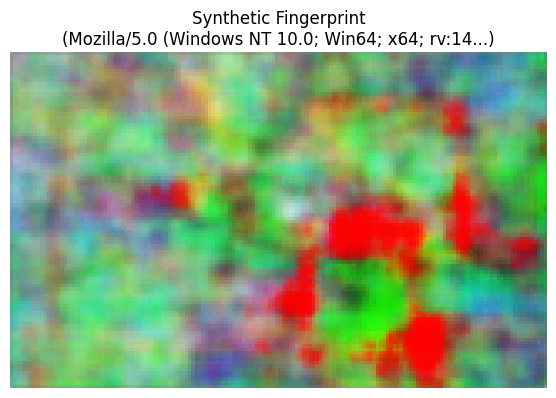

Generating 5 samples for: Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:149.0) Gecko/20100101 Firefox/149.0
Finished


In [8]:
user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:149.0) Gecko/20100101 Firefox/149.0"
generate_and_visualize(model_weights, target_user_agent=user_agent)

outputs = generate_output_list(model_weights, target_user_agent=user_agent, num_samples=5)
with open("generated_fingerprints.json", "w") as f:
    json.dump(outputs, f, indent=4)

Learning curve saved as 'learning_curve.png'


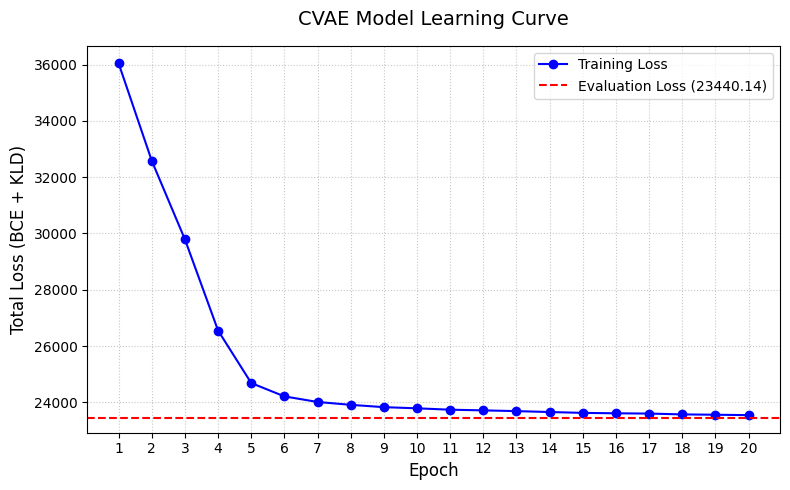

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curve():
	# Data extracted from the training output
	epochs = list(range(1, 21))
	losses = [
		36038.6621, 32578.8770, 29786.5501, 26550.3714, 24686.4506,
		24213.2376, 24015.1136, 23913.1638, 23830.6494, 23789.2930,
		23740.6260, 23716.4179, 23689.8275, 23657.7118, 23627.7073,
		23612.3943, 23602.8973, 23573.4790, 23561.3341, 23547.2914
	]

	# Create the plot
	plt.figure(figsize=(8, 5))
	plt.plot(epochs, losses, marker='o', linestyle='-', color='b', label='Training Loss')

	# Add an evaluation benchmark line
	eval_loss = 23440.1382
	plt.axhline(y=eval_loss, color='r', linestyle='--', label=f'Evaluation Loss ({eval_loss:.2f})')

	# Formatting the chart
	plt.title('CVAE Model Learning Curve', fontsize=14, pad=15)
	plt.xlabel('Epoch', fontsize=12)
	plt.ylabel('Total Loss (BCE + KLD)', fontsize=12)
	plt.xticks(epochs) # Ensure every epoch is labeled on the x-axis
	plt.grid(True, linestyle=':', alpha=0.7)
	plt.legend()

	# Optimize layout and display
	plt.tight_layout()

	# Save the chart as an image to easily import into your presentation
	plt.savefig('learning_curve.png', dpi=300)
	print("Learning curve saved as 'learning_curve.png'")

	# Display the chart
	plt.show()

if __name__ == "__main__":
	plot_learning_curve()